<a href="https://colab.research.google.com/github/ManjunathAdi/Bandits/blob/main/Contextual_Bandits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Contextual Bandits-**
Let's dive deeply into **contextual bandits**, focusing on a real-world recommendation scenario with ads and user features. We will build the understanding step-by-step, including the mathematical framework, code implementation, and explanation.

What is a Contextual Bandit?

In contextual bandits, the goal is to personalize recommendations based on context (user features). Unlike traditional multi-armed bandits, where each arm (ad) has a fixed probability of reward, contextual bandits use user features to predict which ad (arm) is likely to perform best for that specific user.

# Real-World Scenario: Ads Recommendation
Imagine we run an online store where users are shown one of several ads based on their demographic and behavioral features. We want to optimize the click-through rate (CTR) by learning which ad to show to each user based on the context (user features). Here’s how it works:
* Ads (Arms): We have 4 ads to show to users:
  * Ad A: Discounts on shoes.
  * Ad B: New jackets collection.
  * Ad C: 50% off on bags.
  * Ad D: Trending accessories.
* User Features (Context): Each user has a set of features:
  * Age: Younger users may prefer trendy accessories, while older users may look for discounts on shoes.
  * Gender: Some ads may appeal more to men or women.
  * Browsing History: Users who previously purchased jackets might prefer new jacket collections.

# Mathematical Foundation of Contextual Bandits (LinUCB)

The LinUCB algorithm is one of the most popular contextual bandit algorithms. It assumes a linear relationship between the user features (context) and the reward (click on the ad).

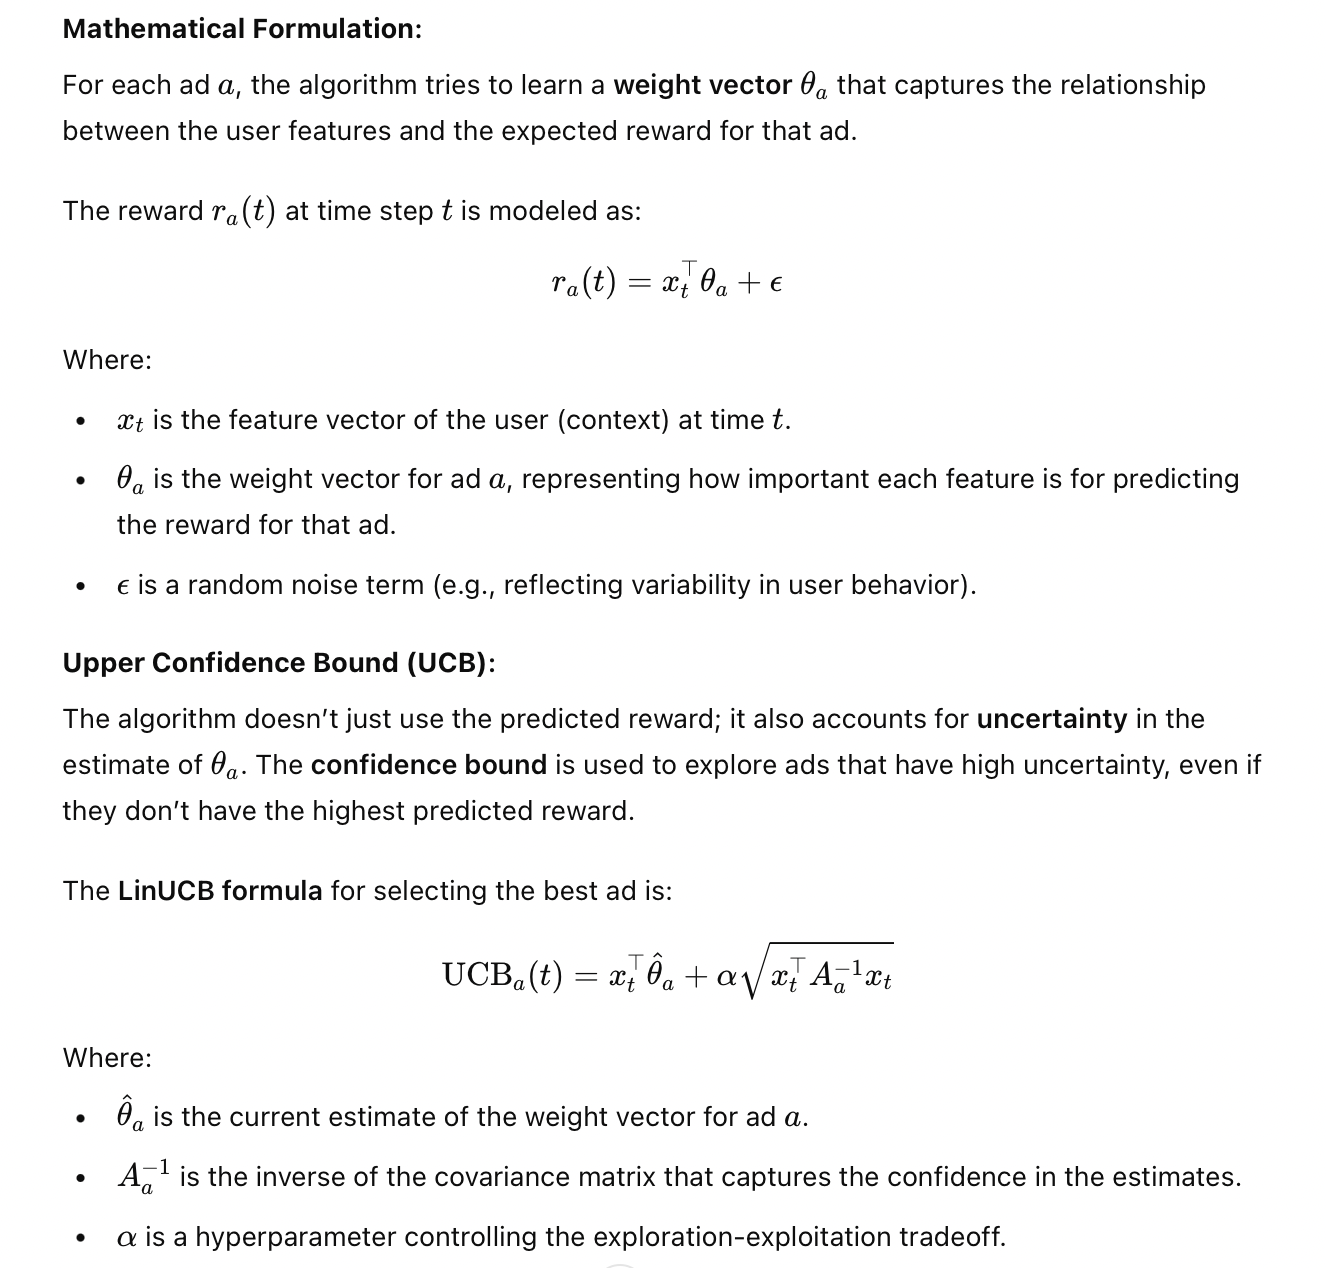

# Step-by-Step Code Implementation of LinUCB

### Step 1: Simulate Ads, User Features, and Rewards

Explanation:
* User Features: We simulate a dataset where each user has a feature vector (e.g., age, gender, browsing history).
* True Weights: For each ad, we generate a set of true weights
θ
θ that determine how much each feature affects the reward (click probability).
* Rewards: We generate a reward for each ad and each user by taking the dot product of the user’s feature vector and the ad’s true weights, adding some noise to simulate real-world variability. We convert this to a binary outcome (click or no click).

In [ ]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Number of ads (arms) and user features
n_arms = 4
n_features = 5  # Age, Gender, Browsing History, etc.
n_users = 10000

# Simulate user features (context)
user_features = np.random.rand(n_users, n_features)  # Random user features between 0 and 1

# Simulate true weights for each ad (unknown to the algorithm)
true_theta = np.random.rand(n_arms, n_features)

# Simulate rewards for each ad based on user features
# Add some random noise to simulate real-world scenarios
rewards = np.dot(user_features, true_theta.T) + np.random.randn(n_users, n_arms) * 0.1

# Convert rewards to binary (0 = no click, 1 = click) based on a threshold
rewards_binary = (rewards > np.random.uniform(0, 1, rewards.shape)).astype(int)

# Create a DataFrame for rewards
df_rewards = pd.DataFrame(rewards_binary, columns=[f'Ad_{i+1}' for i in range(n_arms)])

# Sample user feature set and rewards
df_rewards.head(), user_features[:5]


(   Ad_1  Ad_2  Ad_3  Ad_4
 0     1     1     1     1
 1     1     1     1     1
 2     1     1     1     1
 3     1     1     1     1
 4     1     0     1     1,
 array([[0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864],
        [0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258],
        [0.02058449, 0.96990985, 0.83244264, 0.21233911, 0.18182497],
        [0.18340451, 0.30424224, 0.52475643, 0.43194502, 0.29122914],
        [0.61185289, 0.13949386, 0.29214465, 0.36636184, 0.45606998]]))

# Step 2: LinUCB Algorithm Implementation
Now that we have the simulated data, let’s implement the LinUCB algorithm to recommend ads based on user features.

In [ ]:
class LinUCB:
    def __init__(self, n_arms, n_features, alpha=0.1):
        self.n_arms = n_arms
        self.n_features = n_features
        self.alpha = alpha

        # Initialize parameters for each arm
        self.A = [np.identity(n_features) for _ in range(n_arms)]  # Covariance matrix for each arm
        self.b = [np.zeros(n_features) for _ in range(n_arms)]  # Bias term for each arm

    def select_arm(self, user_features):
        ucb_values = []

        # Calculate UCB for each arm
        for arm in range(self.n_arms):
            A_inv = np.linalg.inv(self.A[arm])
            theta = A_inv.dot(self.b[arm])  # Estimate of weight vector for this arm
            ucb = user_features.dot(theta) + self.alpha * np.sqrt(user_features.dot(A_inv).dot(user_features))
            ucb_values.append(ucb)

        return np.argmax(ucb_values)  # Return the arm with the highest UCB value

    def update(self, chosen_arm, user_features, reward):
        # Update the covariance matrix and bias term for the chosen arm
        self.A[chosen_arm] += np.outer(user_features, user_features)  # A = A + x * x^T
        self.b[chosen_arm] += reward * user_features  # b = b + reward * x


In [ ]:
# Initialize LinUCB algorithm
linucb = LinUCB(n_arms=n_arms, n_features=n_features, alpha=0.1)

# Simulate running the LinUCB algorithm
n_rounds = 10000
rewards_linucb = []
chosen_arms_linucb = []

for t in range(n_rounds):
    user_context = user_features[t]  # Get the user features for this round
    chosen_arm = linucb.select_arm(user_context)
    reward = df_rewards[f'Ad_{chosen_arm+1}'].iloc[t]  # Simulated reward from data
    linucb.update(chosen_arm, user_context, reward)

    rewards_linucb.append(reward)
    chosen_arms_linucb.append(chosen_arm)

# Average reward over time
average_reward_linucb = np.cumsum(rewards_linucb) / (np.arange(n_rounds) + 1)


Explanation:
* select_arm: This function computes the UCB for each ad (arm) using the user’s feature vector and the current estimate of the ad’s weight vector
θ
θ. It selects the ad with the highest UCB value.
* update: After an ad is shown and a reward (click or no click) is observed, the algorithm updates the weight vector for the chosen ad using the user's features and the reward. The covariance matrix
A
A and bias vector
b
b are updated accordingly.

# Step 3: Evaluate Performance
We can now evaluate how well the algorithm performs by plotting the average cumulative reward (click-through rate) over time.

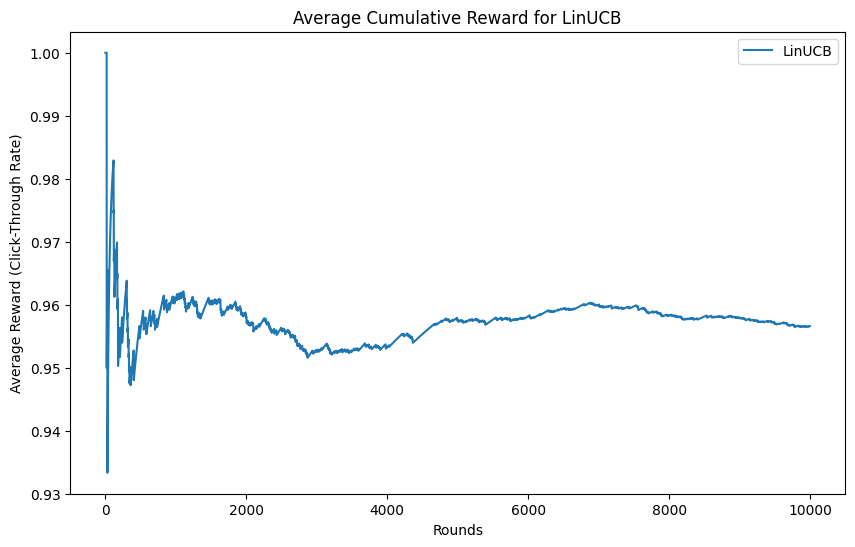

In [ ]:
import matplotlib.pyplot as plt

# Plot cumulative reward
plt.figure(figsize=(10, 6))
plt.plot(average_reward_linucb, label="LinUCB")
plt.title("Average Cumulative Reward for LinUCB")
plt.xlabel("Rounds")
plt.ylabel("Average Reward (Click-Through Rate)")
plt.legend()
plt.show()


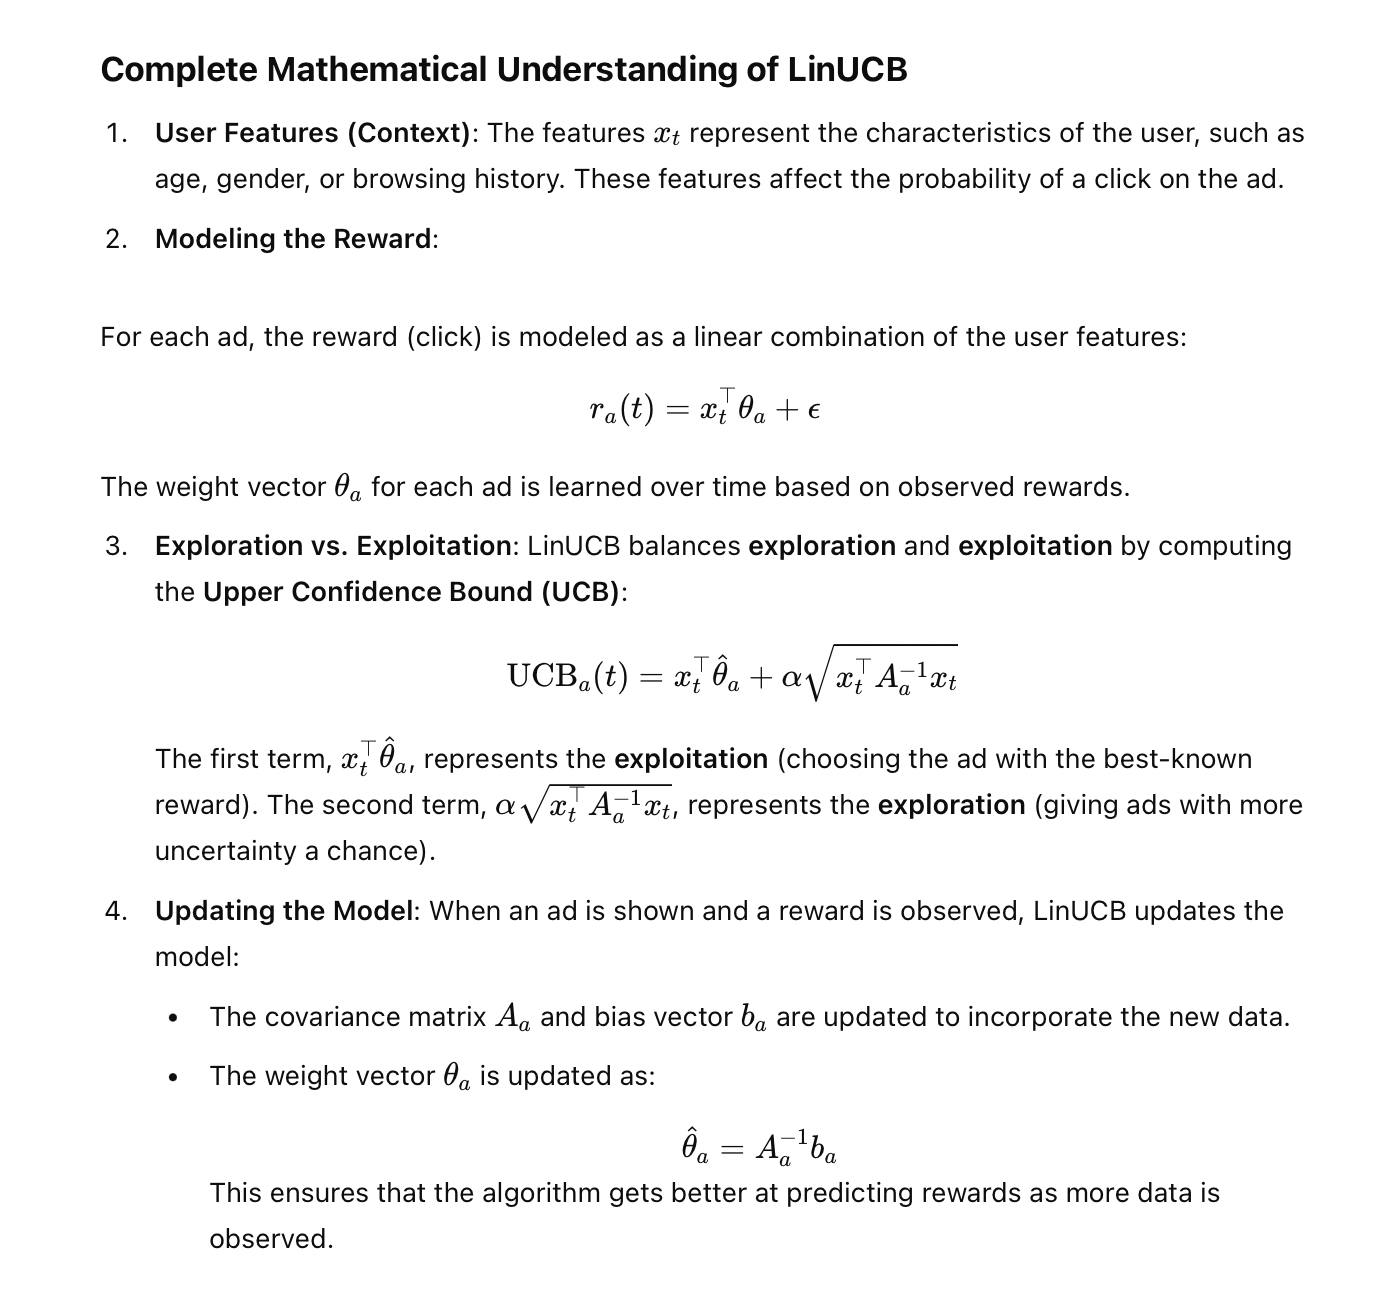

# **Summary**
In this deep dive into **contextual bandits**, specifically **LinUCB**, we covered:
* **How LinUCB works:** It models the relationship between user features (context) and the reward for each ad.
* **How exploration and exploitation are balanced:** Using the Upper Confidence Bound (UCB), LinUCB explores ads with high uncertainty and exploits ads with known good performance.
* **Real-world simulation:** We simulated ads, user features, and rewards to demonstrate how LinUCB learns to recommend the best ad based on user context.

By understanding the mathematical foundations and implementing the algorithm step by step, you can see how **contextual bandits** can be used for personalized ad recommendations, improving user engagement through tailored experiences.

# **2. Neural Bandit (Neural Contextual Bandit)-**

The Neural Bandit algorithm uses a neural network to model the relationship between user features and the expected reward for each ad. Neural Bandits are more flexible than linear models like LinUCB because they can capture non-linear relationships between features and rewards.

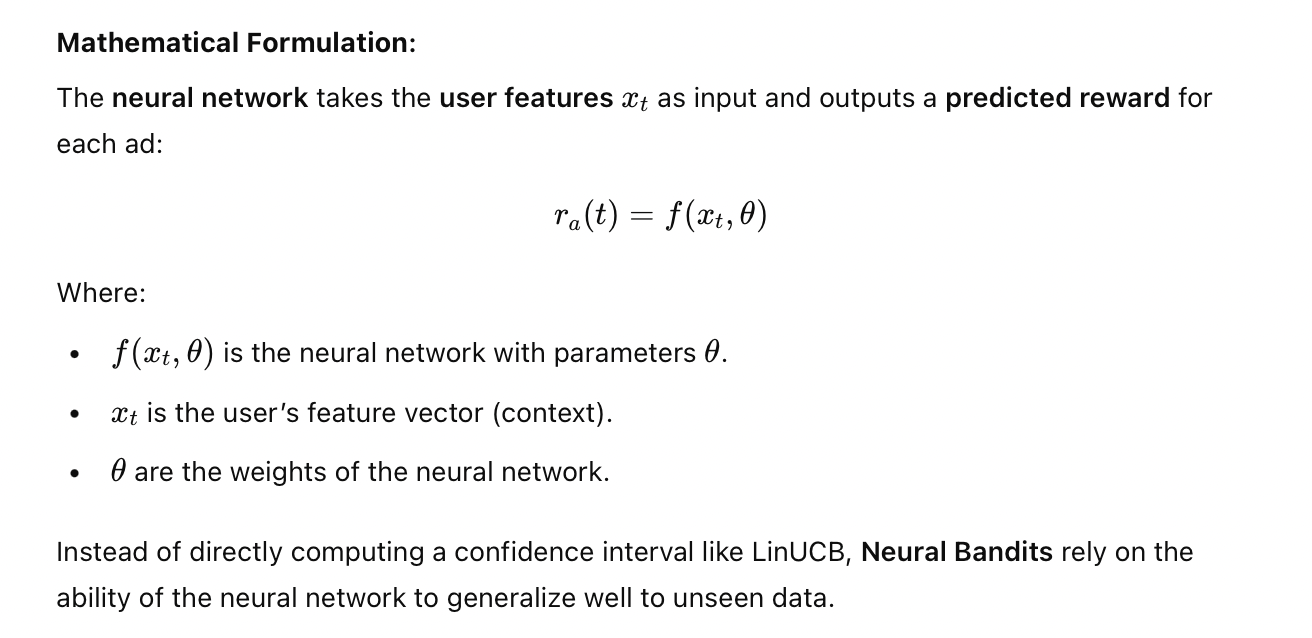


### Step-by-Step Code Implementation:
We will implement the Neural Bandit using PyTorch to model the contextual bandit.

Explanation:

* Neural Network: We define a neural network with 3 fully connected layers to take user features as input and predict reward for each ad.
* Selection: The neural network predicts the rewards for all ads, and we choose the ad with the highest predicted reward.
* Update: After observing the reward for the chosen ad, we update the neural network by adjusting the weights using backpropagation.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the neural network model for the contextual bandit
class NeuralBanditModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(NeuralBanditModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Define the Neural Bandit agent
class NeuralBandit:
    def __init__(self, input_dim, n_arms, lr=0.001):
        self.model = NeuralBanditModel(input_dim, n_arms)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.criterion = nn.MSELoss()

    def select_arm(self, user_features):
        with torch.no_grad():
            user_features = torch.FloatTensor(user_features).unsqueeze(0)
            predictions = self.model(user_features)
            return torch.argmax(predictions).item()

    def update(self, user_features, chosen_arm, reward):
        self.optimizer.zero_grad()
        user_features = torch.FloatTensor(user_features).unsqueeze(0)
        predictions = self.model(user_features)
        target = predictions.clone().detach()
        target[0, chosen_arm] = reward
        loss = self.criterion(predictions, target)
        loss.backward()
        self.optimizer.step()


In [ ]:
# Initialize Neural Bandit agent
neural_bandit = NeuralBandit(input_dim=n_features, n_arms=n_arms, lr=0.001)

# Simulate running the Neural Bandit algorithm
rewards_neural = []
chosen_arms_neural = []

for t in range(n_rounds):
    user_context = user_features[t]
    chosen_arm = neural_bandit.select_arm(user_context)
    reward = df_rewards[f'Ad_{chosen_arm+1}'].iloc[t]
    neural_bandit.update(user_context, chosen_arm, reward)

    rewards_neural.append(reward)
    chosen_arms_neural.append(chosen_arm)

# Average reward over time
average_reward_neural = np.cumsum(rewards_neural) / (np.arange(n_rounds) + 1)


# **3. Thompson Sampling for Contextual Bandits**

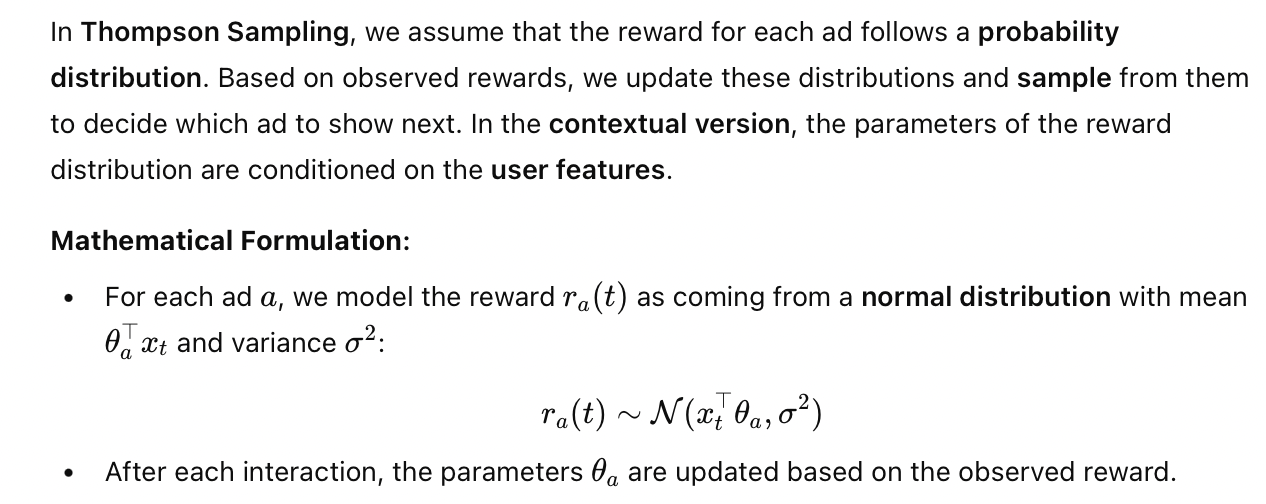

In [ ]:
class ThompsonSamplingContextual:
    def __init__(self, n_arms, n_features, alpha=1.0):
        self.n_arms = n_arms
        self.n_features = n_features
        self.alpha = alpha
        # Initialize for each arm
        self.A = [alpha * np.identity(n_features) for _ in range(n_arms)]  # Covariance matrix
        self.b = [np.zeros(n_features) for _ in range(n_arms)]  # Bias term for each arm

    def select_arm(self, user_features):
        theta_samples = []
        for arm in range(self.n_arms):
            A_inv = np.linalg.inv(self.A[arm])
            theta_sample = np.random.multivariate_normal(np.dot(A_inv, self.b[arm]), A_inv)
            theta_samples.append(np.dot(user_features, theta_sample))
        return np.argmax(theta_samples)

    def update(self, chosen_arm, user_features, reward):
        self.A[chosen_arm] += np.outer(user_features, user_features)
        self.b[chosen_arm] += reward * user_features


In [ ]:
# Initialize Thompson Sampling Contextual Bandit agent
ts_contextual = ThompsonSamplingContextual(n_arms=n_arms, n_features=n_features)

# Simulate running the Thompson Sampling Contextual algorithm
rewards_ts_contextual = []
chosen_arms_ts_contextual = []

for t in range(n_rounds):
    user_context = user_features[t]
    chosen_arm = ts_contextual.select_arm(user_context)
    reward = df_rewards[f'Ad_{chosen_arm+1}'].iloc[t]
    ts_contextual.update(chosen_arm, user_context, reward)

    rewards_ts_contextual.append(reward)
    chosen_arms_ts_contextual.append(chosen_arm)

# Average reward over time
average_reward_ts_contextual = np.cumsum(rewards_ts_contextual) / (np.arange(n_rounds) + 1)


Explanation:

* Sampling: At each round, we sample a possible reward
r
^
a(t) for each ad by drawing from the posterior distribution of
θ
a.
* Selection: The ad with the highest sampled reward is chosen.
* Update: After observing the reward, the covariance matrix
A and bias b are updated for the chosen ad.

# **4. Epsilon-Greedy Contextual Bandit**



**How It Works:**

The Epsilon-Greedy Contextual Bandit works similarly to the basic ε-Greedy algorithm, but it incorporates user features. Most of the time, it exploits by selecting the ad with the highest predicted reward based on the context, but with probability ϵ, it randomly explores another ad.

**Mathematical Formulation:**

With probability 1−ϵ, choose the ad with the highest predicted reward.
With probability ϵ, choose a random ad.

In [ ]:
class EpsilonGreedyContextual:
    def __init__(self, n_arms, n_features, epsilon=0.1):
        self.n_arms = n_arms
        self.n_features = n_features
        self.epsilon = epsilon
        self.A = [np.identity(n_features) for _ in range(n_arms)]  # Covariance matrix for each arm
        self.b = [np.zeros(n_features) for _ in range(n_arms)]  # Bias term for each arm

    def select_arm(self, user_features):
        if np.random.random() > self.epsilon:
            values = []
            for arm in range(self.n_arms):
                A_inv = np.linalg.inv(self.A[arm])
                theta = A_inv.dot(self.b[arm])
                values.append(user_features.dot(theta))
            return np.argmax(values)
        else:
            return np.random.randint(self.n_arms)

    def update(self, chosen_arm, user_features, reward):
        self.A[chosen_arm] += np.outer(user_features, user_features)
        self.b[chosen_arm] += reward * user_features

In [ ]:
# Initialize Epsilon-Greedy Contextual Bandit agent
epsilon_greedy_contextual = EpsilonGreedyContextual(n_arms=n_arms, n_features=n_features, epsilon=0.1)

# Simulate running the Epsilon-Greedy Contextual Bandit algorithm
rewards_eg_contextual = []
chosen_arms_eg_contextual = []

for t in range(n_rounds):
    user_context = user_features[t]
    chosen_arm = epsilon_greedy_contextual.select_arm(user_context)
    reward = df_rewards[f'Ad_{chosen_arm+1}'].iloc[t]
    epsilon_greedy_contextual.update(chosen_arm, user_context, reward)

    rewards_eg_contextual.append(reward)
    chosen_arms_eg_contextual.append(chosen_arm)

# Average reward over time
average_reward_eg_contextual = np.cumsum(rewards_eg_contextual) / (np.arange(n_rounds) + 1)


## **Evaluation Metrics:**
* **Average Cumulative Reward (Click-Through Rate):** This measures how many clicks (rewards) each algorithm achieves on average over time. A higher cumulative reward means the algorithm is performing better.
* **Regret:** Cumulative regret is the difference between the total reward an algorithm could have achieved if it always chose the best ad and the total reward it actually achieved. The lower the regret, the better the algorithm is at learning the optimal strategy.


In [ ]:
average_reward_eg_contextual.shape, average_reward_linucb.shape, average_reward_neural.shape, average_reward_ts_contextual.shape

((10000,), (10000,), (10000,), (10000,))

Now we will plot the **average cumulative rewards** to compare how each algorithm performs over time.

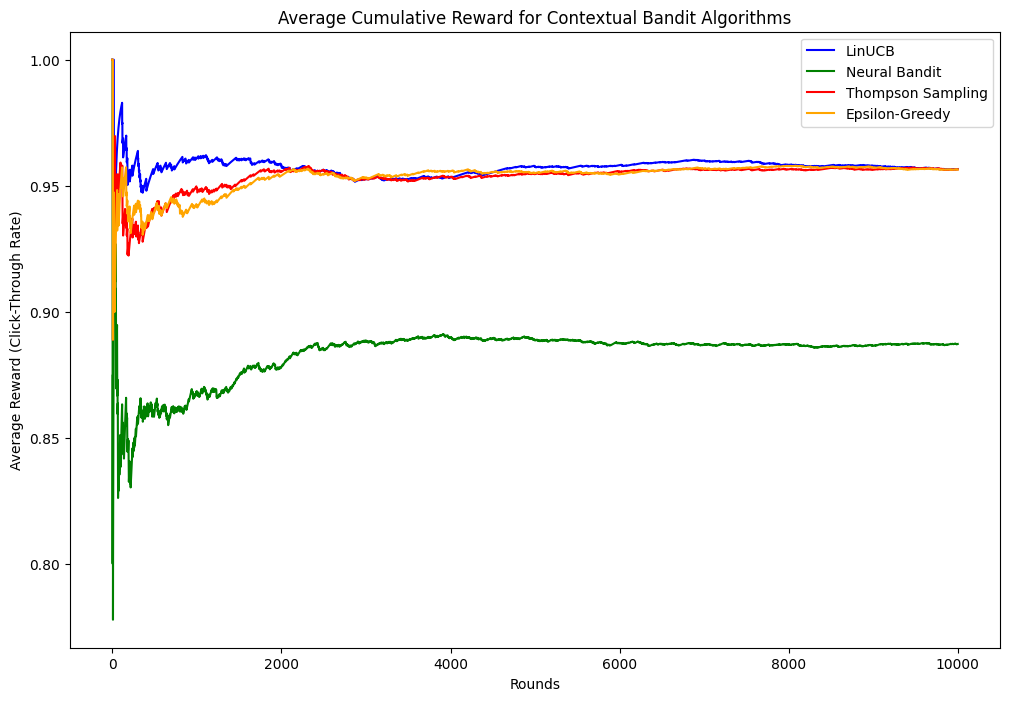

In [ ]:
import matplotlib.pyplot as plt

# Plot the average cumulative reward for each algorithm
plt.figure(figsize=(12, 8))

plt.plot(average_reward_linucb, label="LinUCB", color="blue")
plt.plot(average_reward_neural, label="Neural Bandit", color="green")
plt.plot(average_reward_ts_contextual, label="Thompson Sampling", color="red")
plt.plot(average_reward_eg_contextual, label="Epsilon-Greedy", color="orange")

plt.title("Average Cumulative Reward for Contextual Bandit Algorithms")
plt.xlabel("Rounds")
plt.ylabel("Average Reward (Click-Through Rate)")
plt.legend()
plt.show()


### **Interpretation of Results:**
* **LinUCB:** Performs well if the relationship between user features and rewards is linear. The exploration-exploitation tradeoff is handled via confidence bounds.
* **Neural Bandit:** If the relationship between user features and rewards is non-linear, Neural Bandits will capture these complex relationships better. However, it may take more rounds to converge due to the complexity of the model.
* **Thompson Sampling:** This algorithm is strong in terms of balancing exploration and exploitation. It samples from the posterior distribution, which allows it to explore efficiently.
* **Epsilon-Greedy:** It is simple and works decently, but since exploration is random, it may not perform as well as algorithms with smarter exploration strategies (like LinUCB or Thompson Sampling).

 Calculate and Compare **Regret** :

Cumulative Regret shows how far each algorithm is from the optimal performance. The lower the regret, the better the algorithm performed in finding the best ads.

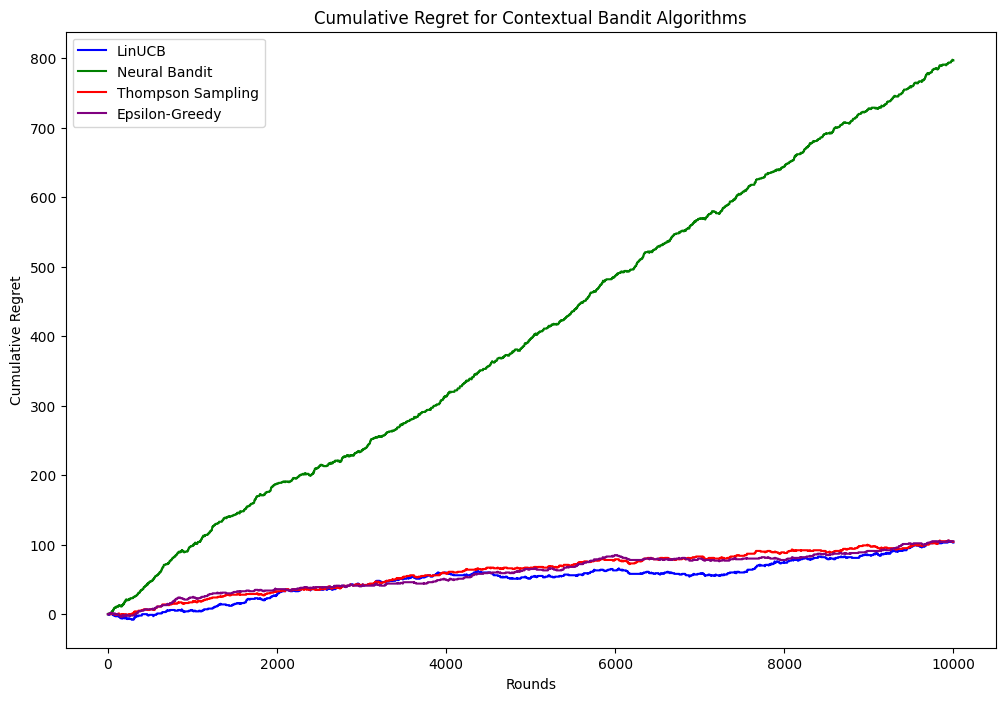

In [ ]:
# Define the optimal arm (ad with the highest average reward)
optimal_arm = np.argmax([df_rewards[f'Ad_{i+1}'].mean() for i in range(n_arms)])
optimal_rewards = df_rewards[f'Ad_{optimal_arm+1}']

# Function to calculate regret
def calculate_regret(chosen_arms, rewards, optimal_rewards):
    cumulative_rewards = np.cumsum(rewards)
    optimal_cumulative_rewards = np.cumsum(optimal_rewards[:len(rewards)])
    regret = optimal_cumulative_rewards - cumulative_rewards
    return regret

# Calculate regret for each algorithm
regret_linucb = calculate_regret(chosen_arms_linucb, rewards_linucb, optimal_rewards)
regret_neural = calculate_regret(chosen_arms_neural, rewards_neural, optimal_rewards)
regret_ts_contextual = calculate_regret(chosen_arms_ts_contextual, rewards_ts_contextual, optimal_rewards)
regret_eg_contextual = calculate_regret(chosen_arms_eg_contextual, rewards_eg_contextual, optimal_rewards)

# Plot cumulative regret for each algorithm
plt.figure(figsize=(12, 8))

plt.plot(regret_linucb, label="LinUCB", color="blue")
plt.plot(regret_neural, label="Neural Bandit", color="green")
plt.plot(regret_ts_contextual, label="Thompson Sampling", color="red")
plt.plot(regret_eg_contextual, label="Epsilon-Greedy", color="purple")

plt.title("Cumulative Regret for Contextual Bandit Algorithms")
plt.xlabel("Rounds")
plt.ylabel("Cumulative Regret")
plt.legend()
plt.show()


### **Interpretation of Cumulative Regret:**
* Lower regret indicates that the algorithm is efficiently learning the optimal ads to show to users.
* Algorithms like Thompson Sampling and LinUCB generally perform well because they balance exploration and exploitation more intelligently.
* Epsilon-Greedy may have higher regret due to its simpler random exploration strategy.
* Neural Bandit might initially have higher regret because of its complexity, but over time, it should perform better if the relationship between features and rewards is non-linear.

# **Summary of Contextual Bandit Algorithms**

* **LinUCB:** Assumes a linear relationship between user features and rewards, using confidence bounds to balance exploration and exploitation.
* **Neural Bandit:** Uses a neural network to model the non-linear relationship between user features and rewards.
* **Thompson Sampling for Contextual Bandits:** Samples from the posterior distribution of the reward parameters to balance exploration and exploitation.
* **Epsilon-Greedy Contextual Bandit:** Explores randomly with a fixed probability ϵ and exploits the best-known ad otherwise.

These algorithms offer different ways to solve the exploration-exploitation trade-off in recommendation systems, using user context (features) to personalize decisions.